# Modele de regression - log_roi
Regression lineaire pour estimer le multiple de retour sur investissement.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from boxoffice.modeling.features_ml import load_model_data, NUMERIC_FEATURES

sns.set_theme(style="whitegrid")

X, y_class, y_reg, feature_names = load_model_data()
print(f"X: {X.shape}, y_reg: {y_reg.shape}")
print(y_reg.describe())

[features_ml] 5 lignes avec NaN residuel exclues.
X: (9263, 36), y_reg: (9263,)
count    9263.000000
mean        0.304340
std         1.741149
min        -9.556594
25%        -0.482216
50%         0.565211
75%         1.349597
max         9.464237
Name: log_roi, dtype: float64


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (7410, 36), Test: (1853, 36)


In [3]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

In [4]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [5]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R2: {r2:.3f}")
print(f"RMSE (log_roi): {rmse:.3f}")
print(f"MAE (log_roi): {mae:.3f}")

R2: 0.140
RMSE (log_roi): 1.603
MAE (log_roi): 1.149


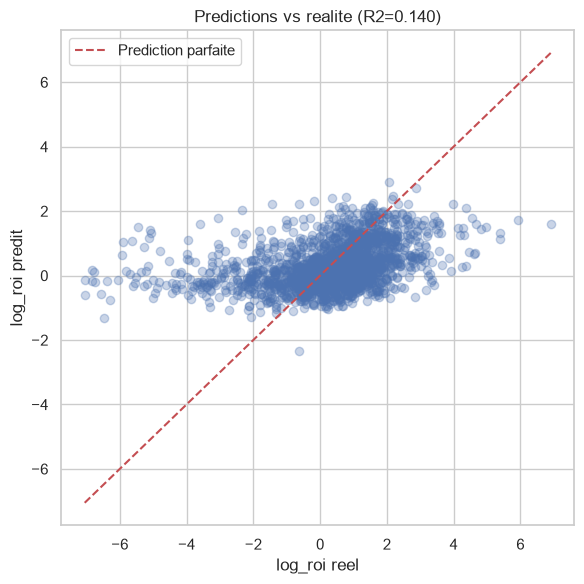

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Prediction parfaite")
plt.xlabel("log_roi reel")
plt.ylabel("log_roi predit")
plt.title(f"Predictions vs realite (R2={r2:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

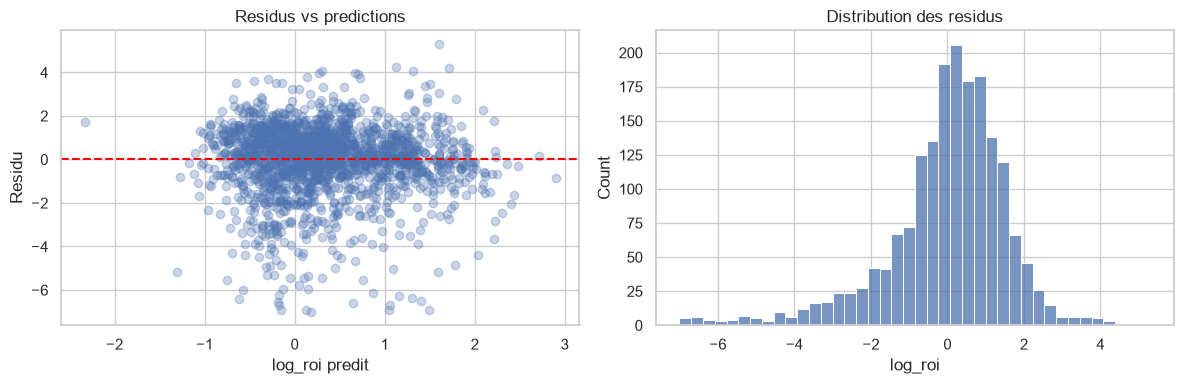

In [7]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("log_roi predit")
axes[0].set_ylabel("Residu")
axes[0].set_title("Residus vs predictions")

sns.histplot(residuals, bins=40, ax=axes[1])
axes[1].set_title("Distribution des residus")
plt.tight_layout()
plt.show()

In [8]:
roi_test_reel = np.exp(y_test)
roi_pred_reel = np.exp(y_pred)

comparison = pd.DataFrame({
    "roi_reel": roi_test_reel.values,
    "roi_predit": roi_pred_reel
}).sample(10, random_state=1)
print(comparison.round(2))

      roi_reel  roi_predit
462       0.03        0.81
1081      2.95        3.68
1178      2.31        1.57
1068      0.26        0.80
372       0.83        0.63
1805      4.42        0.60
241       1.72        0.98
464       2.22        1.08
1427      0.21        2.34
625       3.90        1.25


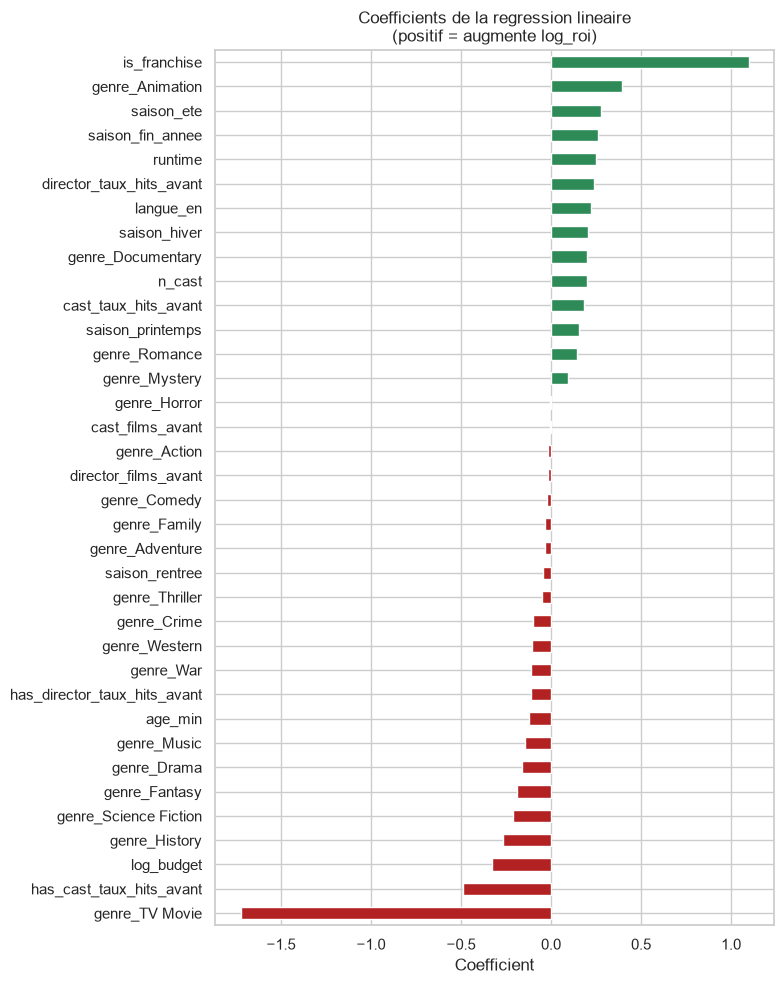

Top 5 favorables au ROI:
is_franchise        1.097520
genre_Animation     0.394141
saison_ete          0.279707
saison_fin_annee    0.259827
runtime             0.251174
dtype: float64

Top 5 defavorables au ROI:
genre_TV Movie             -1.724559
has_cast_taux_hits_avant   -0.489650
log_budget                 -0.325385
genre_History              -0.268557
genre_Science Fiction      -0.211222
dtype: float64


In [9]:
coefs = pd.Series(model.coef_, index=feature_names).sort_values()

plt.figure(figsize=(8, 10))
colors = ["firebrick" if c < 0 else "seagreen" for c in coefs]
coefs.plot(kind="barh", color=colors)
plt.title("Coefficients de la regression lineaire\n(positif = augmente log_roi)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

print("Top 5 favorables au ROI:")
print(coefs.sort_values(ascending=False).head(5))
print("\nTop 5 defavorables au ROI:")
print(coefs.sort_values().head(5))